# 3. Perhitungan & Visualisasi

## A. Proses Crawling & Pemrosesan Data

Tahapan ini mencakup pengumpulan data dari API berdasarkan batas wilayah spasial, hingga pembersihan dan penyimpanan data ke dalam format CSV.

## A. Setup Batas Wilayah GeoJSON
Kita mulai dengan mendefinisikan batas poligon (*Polygon*) wilayah Gresik yang telah disiapkan, lalu mencari titik tengah (*centroid*) dari area tersebut untuk parameter API.

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Polygon

# Definisi koordinat batas wilayah (Gresik) menggunakan GeoJSON
geojson_coords = [
    [112.6568922, -7.1481289],
    [112.6482448, -7.1509091],
    [112.6525927, -7.1672063],
    [112.6657812, -7.1655766],
    [112.6568922, -7.1481289]
]

# Konversi ke bentuk Poligon
area_polygon = Polygon(geojson_coords)

# Mendapatkan koordinat pusat (centroid) untuk API
centroid_lon = area_polygon.centroid.x
centroid_lat = area_polygon.centroid.y
print(f"Titik Pusat Penarikan Data -> Latitude: {centroid_lat:.5f}, Longitude: {centroid_lon:.5f}")

Titik Pusat Penarikan Data -> Latitude: -7.15842, Longitude: 112.65617


```{note}
Ganti daftar `geojson_coords` di atas dengan titik-titik batas wilayah domisili/kajian Anda masing-masing (bukan Gresik) jika tugas mensyaratkan wilayah yang berbeda. Koordinat bisa diambil dari geojson.io atau batas administratif resmi.
```

Untuk memastikan batas wilayah yang dipakai sudah sesuai (bukan hanya berupa angka koordinat), kita bisa memvisualisasikan poligon tersebut di atas peta interaktif menggunakan `folium`:

In [2]:
import folium

# Membuat peta terpusat di centroid wilayah kajian
peta_wilayah = folium.Map(location=[centroid_lat, centroid_lon], zoom_start=13)

# Menambahkan poligon batas wilayah Gresik ke peta
folium.Polygon(
    locations=[(lat, lon) for lon, lat in geojson_coords],
    color='#e74c3c',
    weight=3,
    fill=True,
    fill_opacity=0.2,
    tooltip='Batas Wilayah Kajian - Gresik'
).add_to(peta_wilayah)

# Menandai titik pusat (centroid) tempat data ditarik
folium.Marker(
    location=[centroid_lat, centroid_lon],
    popup='Titik Pengambilan Data API',
    icon=folium.Icon(color='blue', icon='cloud')
).add_to(peta_wilayah)

peta_wilayah

## B. Mengunduh Data dari API
Menggunakan titik pusat tadi, kita menarik data kualitas udara secara historis selama satu tahun ke belakang.

# Setup Parameter Tanggal dan URL (Sampai 31 Agustus 2026)

In [3]:
start_date = "2025-08-31"
end_date = "2026-08-31"
url = "https://air-quality-api.open-meteo.com/v1/air-quality"

params = {
    "latitude": centroid_lat,
    "longitude": centroid_lon,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": "pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone",
    "timezone": "Asia/Jakarta"
}

# Request data

In [4]:
print("Memulai proses crawling...")
response = requests.get(url, params=params)
data = response.json()
print("Data API berhasil ditarik!")

Memulai proses crawling...


Data API berhasil ditarik!


## C. Data Preparation & Penyesuaian Urutan
Setelah data JSON ditarik dari API, kita ubah menjadi DataFrame. Kita juga akan melakukan eksplorasi awal (lihat Bagian 2.4), lalu menghapus anomali nilai negatif, mengisi data yang hilang, dan memastikan urutan data diatur dari yang terlama ke yang terbaru (ascending).

# Memasukkan data ke dalam Pandas DataFrame

In [5]:
df = pd.DataFrame(data['hourly'])
df['time'] = pd.to_datetime(df['time'])

In [6]:
# --- Eksplorasi awal sebelum pembersihan (lihat penjelasan Bagian 2.4) ---
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   time              8784 non-null   datetime64[ns]
 1   pm10              8784 non-null   float64       
 2   pm2_5             8784 non-null   float64       
 3   carbon_monoxide   8784 non-null   float64       
 4   nitrogen_dioxide  8784 non-null   float64       
 5   ozone             8784 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 411.9 KB


In [7]:
df.describe()

,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone
count,8784,8784.000000,8784.000000,8784.00000,8784.000000,8784.000000
mean,2026-03-01 23:30:00,42.603723,41.114857,1053.38536,33.711737,69.815005
min,2025-08-31 00:00:00,6.300000,6.100000,81.00000,2.700000,0.000000
25%,2025-11-30 11:45:00,23.100000,21.500000,494.00000,16.000000,28.000000
50%,2026-03-01 23:30:00,33.600000,31.900000,758.00000,28.200000,53.000000
75%,2026-06-01 11:15:00,51.800000,50.500000,1273.25000,45.900000,107.000000
max,2026-08-31 23:00:00,275.700000,275.700000,8484.00000,195.500000,289.000000
std,NaN,29.907019,29.741924,902.83143,23.489916,54.557600


In [8]:
# Cek jumlah missing values (NaN) di setiap kolom
print("Jumlah data kosong (missing values) per kolom:")
print(df.isna().sum())

Jumlah data kosong (missing values) per kolom:
time                0
pm10                0
pm2_5               0
carbon_monoxide     0
nitrogen_dioxide    0
ozone               0
dtype: int64


In [9]:
# Cek jumlah nilai negatif per kolom SEBELUM dibersihkan
# (nama kolom masih format asli dari API: pm10, pm2_5, carbon_monoxide, nitrogen_dioxide, ozone)
kolom_polutan = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'ozone']
for col in kolom_polutan:
    jumlah_negatif = (df[col] < 0).sum()
    print(f"Jumlah nilai negatif pada {col}: {jumlah_negatif}")

Jumlah nilai negatif pada pm10: 0
Jumlah nilai negatif pada pm2_5: 0
Jumlah nilai negatif pada carbon_monoxide: 0
Jumlah nilai negatif pada nitrogen_dioxide: 0
Jumlah nilai negatif pada ozone: 0


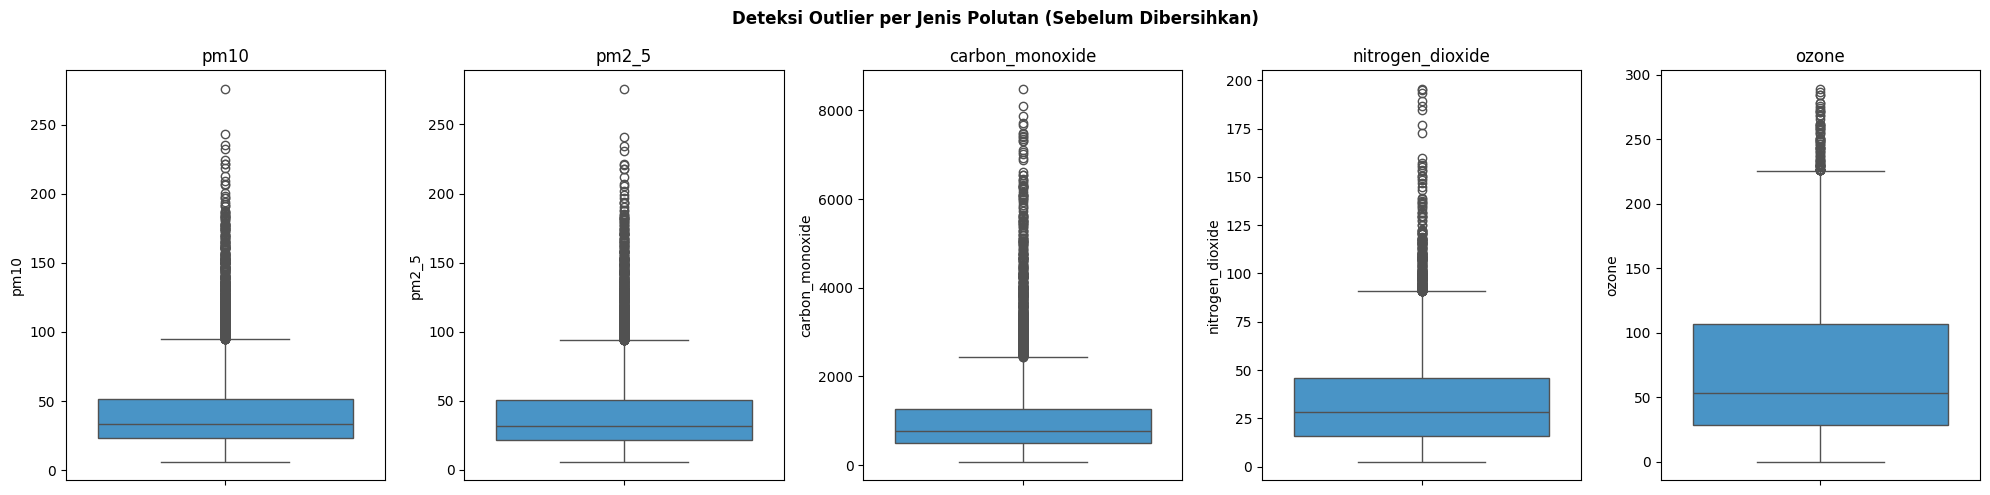

In [10]:
# Deteksi outlier ekstrem menggunakan visualisasi boxplot per kolom polutan (SEBELUM dibersihkan)
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(kolom_polutan):
    sns.boxplot(y=df[col], ax=axes[i], color='#3498db')
    axes[i].set_title(col)
plt.suptitle('Deteksi Outlier per Jenis Polutan (Sebelum Dibersihkan)', fontweight='bold')
plt.tight_layout()
plt.show()

# Mengubah nama kolom agar lebih ringkas

In [11]:
df.rename(columns={
    'carbon_monoxide': 'CO',
    'nitrogen_dioxide': 'NO2',
    'pm10': 'PM10',
    'pm2_5': 'PM2.5',
    'ozone': 'O3'
}, inplace=True)

# Membersihkan anomali: mengubah konsentrasi negatif menjadi Missing Values (NaN)

In [12]:
for col in ['PM10', 'PM2.5', 'CO', 'NO2', 'O3']:
    df.loc[df[col] < 0, col] = None

In [13]:
# Mengisi missing values (NaN) menggunakan interpolasi linear berbasis waktu
# Interpolasi dipilih karena data bersifat time-series dan nilai polutan
# cenderung berubah secara gradual antar-jam, bukan melompat drastis
#
# CATATAN PENTING: method='time' saja TIDAK bisa mengisi NaN yang berada di
# ujung awal atau ujung akhir deret waktu (leading/trailing NaN), karena tidak
# ada titik data di salah satu sisinya untuk diinterpolasi. Oleh karena itu
# ditambahkan limit_direction='both' agar NaN di kedua ujung juga tertangani
# (menggunakan nilai valid terdekat sebagai isian/extrapolasi sederhana).
df = df.set_index('time')
df[['PM10', 'PM2.5', 'CO', 'NO2', 'O3']] = df[['PM10', 'PM2.5', 'CO', 'NO2', 'O3']].interpolate(
    method='time', limit_direction='both'
)
df = df.reset_index()

# Verifikasi ulang tidak ada lagi missing values setelah interpolasi
print("Sisa missing values setelah interpolasi:")
print(df.isna().sum())

Sisa missing values setelah interpolasi:
time     0
PM10     0
PM2.5    0
CO       0
NO2      0
O3       0
dtype: int64


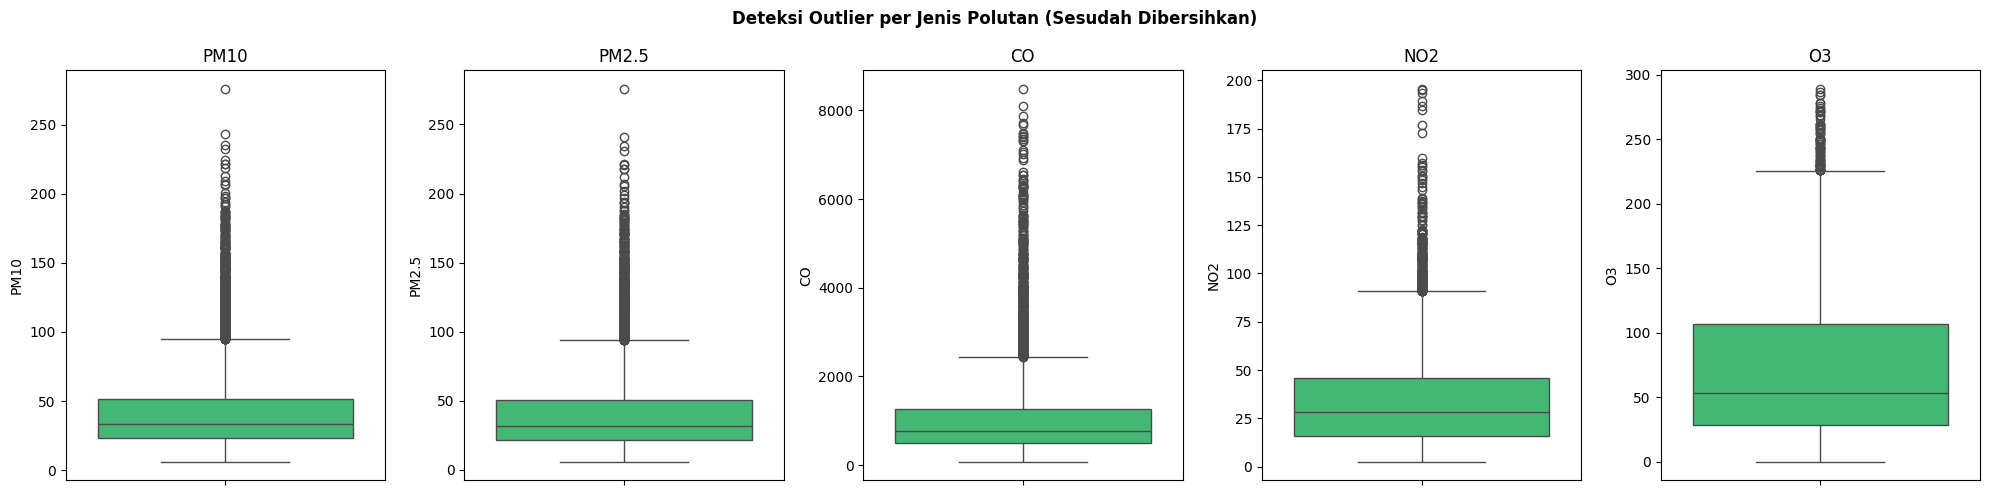

In [14]:
# Deteksi outlier SESUDAH dibersihkan, sebagai pembanding terhadap boxplot sebelumnya.
# Perbandingan ini penting untuk melihat apakah pembersihan nilai negatif juga
# berdampak pada sebaran/outlier data secara keseluruhan.
kolom_polutan_bersih = ['PM10', 'PM2.5', 'CO', 'NO2', 'O3']
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(kolom_polutan_bersih):
    sns.boxplot(y=df[col], ax=axes[i], color='#2ecc71')
    axes[i].set_title(col)
plt.suptitle('Deteksi Outlier per Jenis Polutan (Sesudah Dibersihkan)', fontweight='bold')
plt.tight_layout()
plt.show()

# Catatan interpretasi: outlier yang masih tersisa setelah pembersihan nilai
# negatif tidak serta-merta dihapus, karena bisa jadi merupakan kejadian nyata
# (misalnya lonjakan PM2.5 akibat kebakaran lahan/kemacetan ekstrem), bukan
# error pengukuran. Outlier semacam ini dibiarkan dalam data namun dicatat
# sebagai catatan analisis lanjutan.

# Mengurutkan waktu secara ASCENDING agar runtun waktu rapi (Data terlama di atas)

In [15]:
df = df.sort_values(by='time', ascending=True).reset_index(drop=True)

# Menyimpan Data menjadi CSV

In [16]:
csv_filename = "polutan_gresik_2025_2026.csv"
df.to_csv(csv_filename, index=False)
print(f"Data disimpan ke dalam bentuk file: {csv_filename}")

Data disimpan ke dalam bentuk file: polutan_gresik_2025_2026.csv


# Menampilkan cuplikan data teratas

In [17]:
df.head()

,time,PM10,PM2.5,CO,NO2,O3
0,2025-08-31 00:00:00,30.7,29.5,860.0,27.3,35.0
1,2025-08-31 01:00:00,39.1,37.6,911.0,29.3,30.0
2,2025-08-31 02:00:00,49.1,47.5,1077.0,31.7,24.0
3,2025-08-31 03:00:00,55.3,53.4,1303.0,34.4,17.0
4,2025-08-31 04:00:00,58.9,56.8,1507.0,36.9,16.0


---

## B. Visualisasi Grafik (Time Series)
Langkah terakhir adalah memvisualisasikan data runtun waktu yang telah bersih untuk melihat pergerakan tren kualitas udaranya, sekaligus menjawab keempat pertanyaan pada Bagian 1.3: tren umum, pola harian, pola musiman, dan frekuensi pelanggaran ambang batas.

## A. Grafik Gas Emisi (CO dan NO2)
Kita me-resample datanya menjadi rata-rata harian agar grafik lebih mudah dibaca dan tidak terlalu menumpuk.

# Resample data per jam menjadi rata-rata harian (D = Daily)

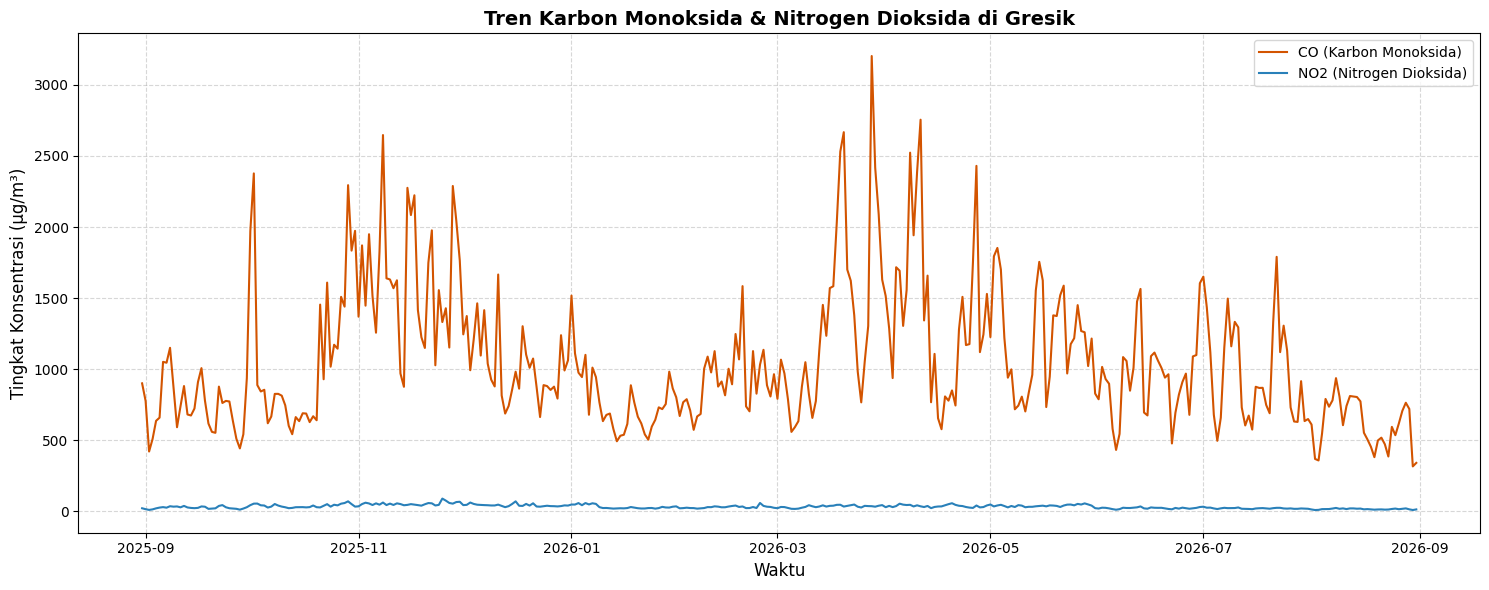

In [18]:
df_daily = df.resample('D', on='time').mean().reset_index()

# Konfigurasi kanvas Matplotlib
plt.figure(figsize=(15, 6))

# Plot Garis untuk Karbon Monoksida dan Nitrogen Dioksida
sns.lineplot(data=df_daily, x='time', y='CO', label='CO (Karbon Monoksida)', color='#d35400')
sns.lineplot(data=df_daily, x='time', y='NO2', label='NO2 (Nitrogen Dioksida)', color='#2980b9')

# Styling Grafik
plt.title('Tren Karbon Monoksida & Nitrogen Dioksida di Gresik', fontsize=14, fontweight='bold')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Tingkat Konsentrasi (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## B. Grafik Partikel Berbahaya (PM10 dan PM2.5)
Partikulat sangat penting dipantau di wilayah pabrik dan kendaraan berat karena bentuk fisiknya berupa debu mikro yang berbahaya bagi pernapasan.

# Konfigurasi kanvas Matplotlib

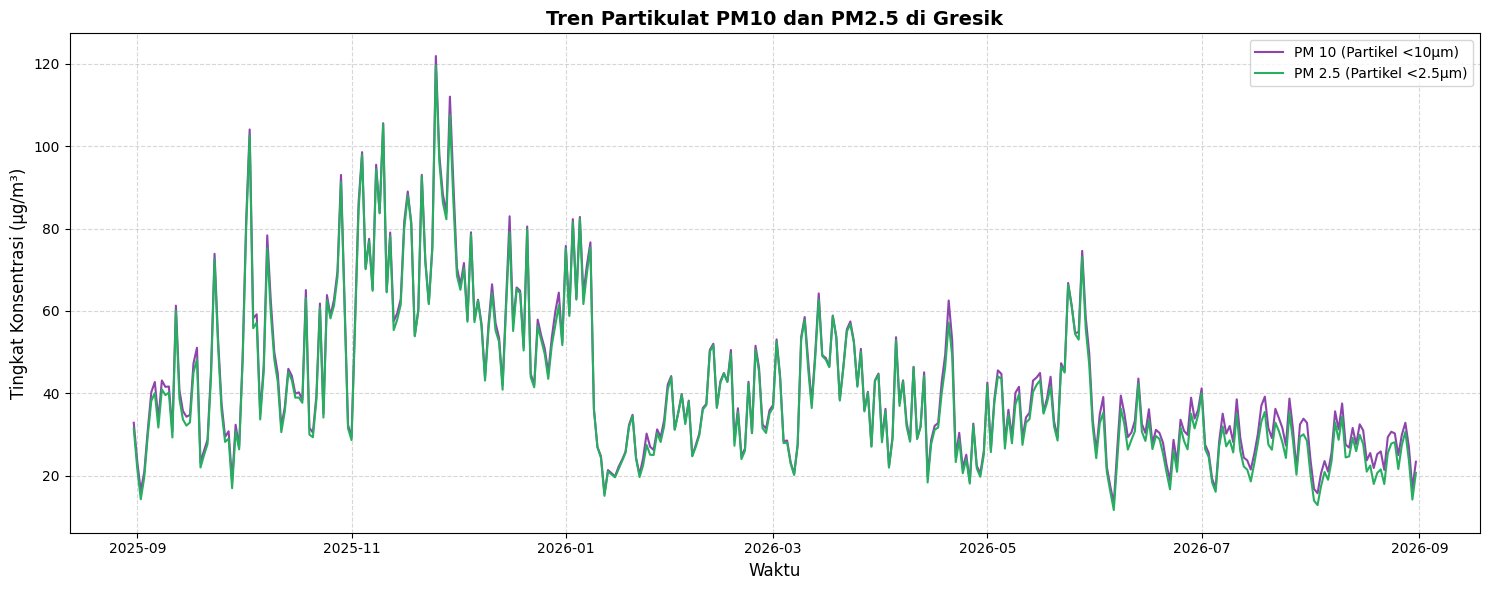

In [19]:
plt.figure(figsize=(15, 6))

# Plot Garis untuk Partikulat
sns.lineplot(data=df_daily, x='time', y='PM10', label='PM 10 (Partikel <10µm)', color='#8e44ad')
sns.lineplot(data=df_daily, x='time', y='PM2.5', label='PM 2.5 (Partikel <2.5µm)', color='#27ae60')

# Styling Grafik
plt.title('Tren Partikulat PM10 dan PM2.5 di Gresik', fontsize=14, fontweight='bold')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Tingkat Konsentrasi (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## C. Grafik Ozon Permukaan (O3)
Karena O3 terbentuk dari reaksi fotokimia, polanya cenderung berbeda dengan polutan hasil emisi langsung (CO, NO2), sehingga divisualisasikan secara terpisah.

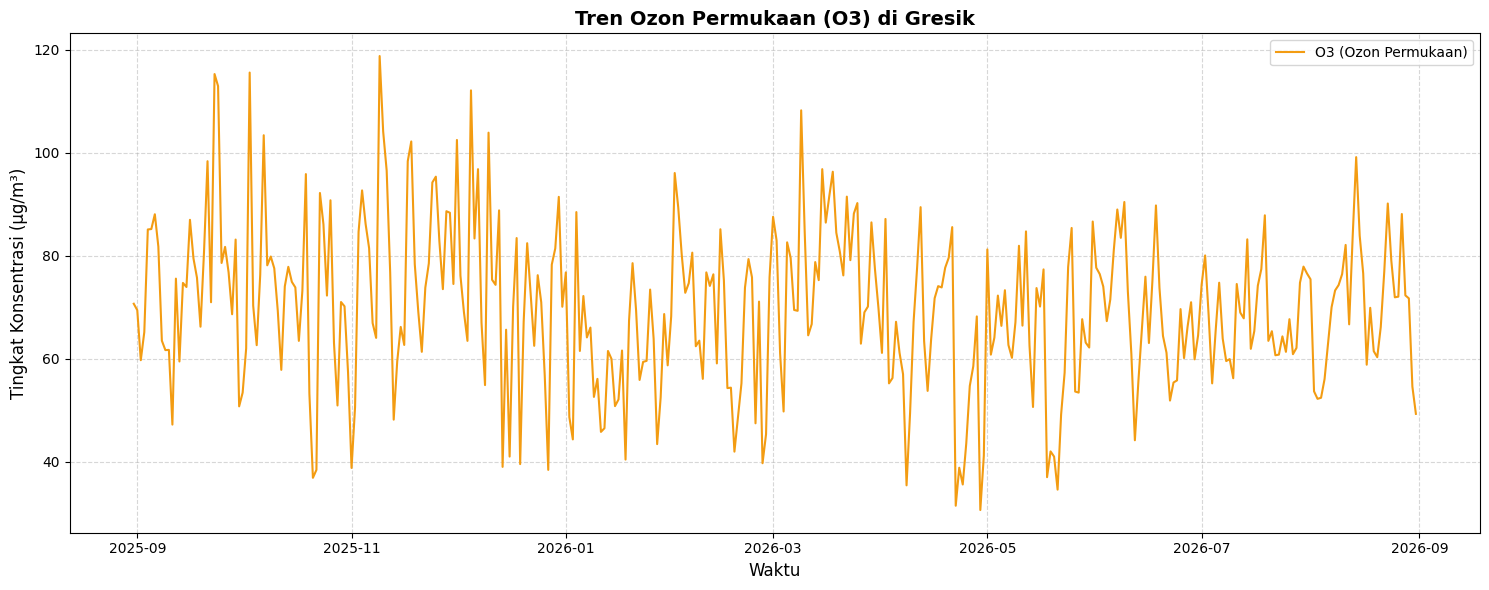

In [20]:
plt.figure(figsize=(15, 6))

sns.lineplot(data=df_daily, x='time', y='O3', label='O3 (Ozon Permukaan)', color='#f39c12')

plt.title('Tren Ozon Permukaan (O3) di Gresik', fontsize=14, fontweight='bold')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Tingkat Konsentrasi (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## D. Pola Harian (Jam Sibuk Lalu Lintas)

Grafik pada Bagian A–C menggunakan rata-rata harian sehingga pola dalam satu hari (24 jam) tidak terlihat. Bagian ini secara khusus menjawab pertanyaan riset "apakah polusi lebih tinggi di jam sibuk lalu lintas?" dengan mengelompokkan data berdasarkan jam (0–23) tanpa memandang tanggal.

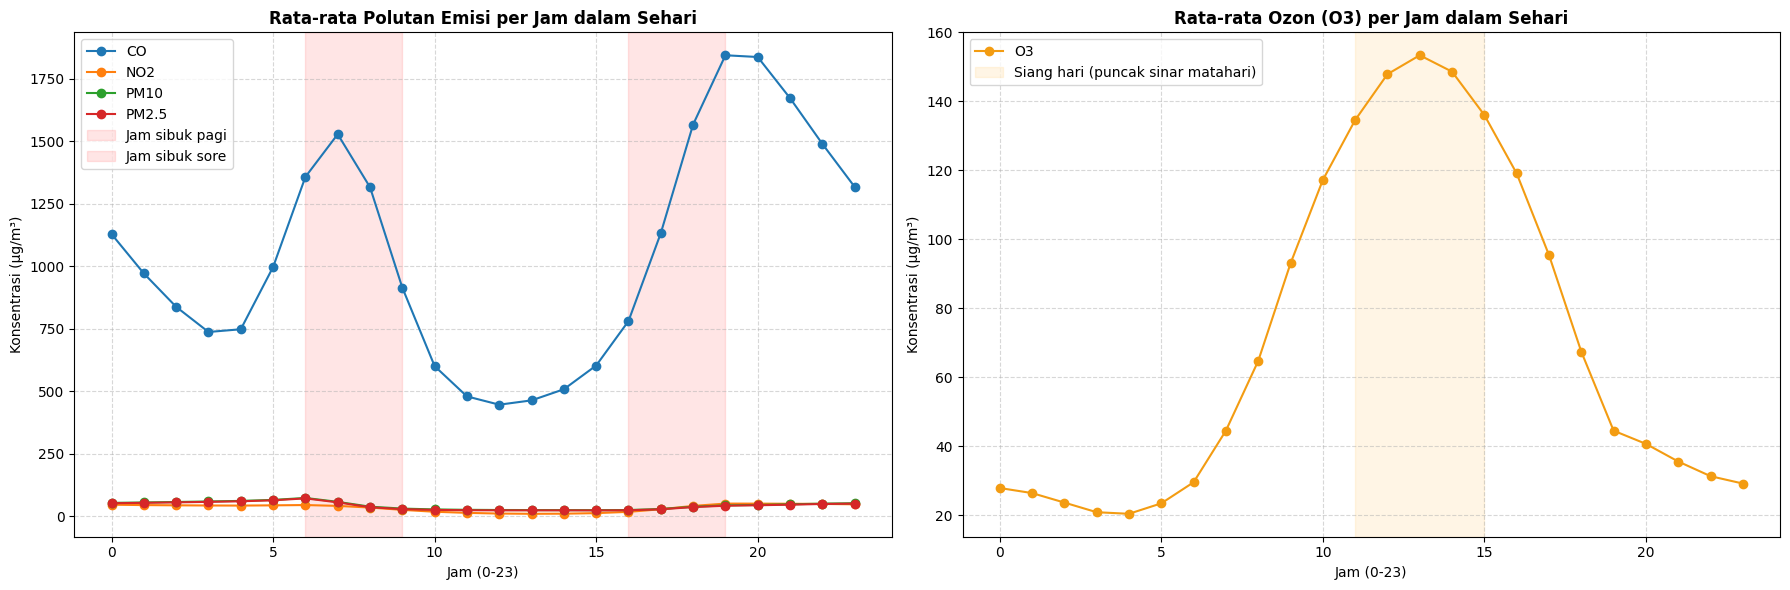

,CO,NO2,PM10,PM2.5,O3
hour,,,,,
0,1128.816940,45.653005,53.005464,51.517486,27.893443
1,971.319672,44.200000,54.681967,53.181967,26.426230
2,837.715847,43.240164,56.562842,55.054372,23.669399
3,737.065574,42.567486,58.638525,57.109836,20.877049
4,747.934426,42.182787,60.980874,59.435519,20.418033
5,997.090164,43.132514,64.839891,63.265574,23.448087
6,1357.808743,44.371311,72.777596,71.066120,29.560109
7,1528.644809,40.974044,57.071311,55.066393,44.532787
8,1316.475410,34.332514,37.822131,35.673497,64.734973


In [21]:
# Ekstrak jam dari kolom waktu (0-23)
df['hour'] = df['time'].dt.hour

# Rata-rata konsentrasi per jam sepanjang periode data
df_hourly_pattern = df.groupby('hour')[['CO', 'NO2', 'PM10', 'PM2.5', 'O3']].mean()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel kiri: polutan emisi langsung dari kendaraan (CO, NO2, PM10, PM2.5)
df_hourly_pattern[['CO', 'NO2', 'PM10', 'PM2.5']].plot(ax=axes[0], marker='o')
axes[0].set_title('Rata-rata Polutan Emisi per Jam dalam Sehari', fontweight='bold')
axes[0].set_xlabel('Jam (0-23)')
axes[0].set_ylabel('Konsentrasi (μg/m³)')
axes[0].axvspan(6, 9, color='red', alpha=0.1, label='Jam sibuk pagi')
axes[0].axvspan(16, 19, color='red', alpha=0.1, label='Jam sibuk sore')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Panel kanan: O3 dipisah karena polanya dibentuk oleh sinar matahari, bukan emisi langsung
df_hourly_pattern[['O3']].plot(ax=axes[1], marker='o', color='#f39c12')
axes[1].set_title('Rata-rata Ozon (O3) per Jam dalam Sehari', fontweight='bold')
axes[1].set_xlabel('Jam (0-23)')
axes[1].set_ylabel('Konsentrasi (μg/m³)')
axes[1].axvspan(11, 15, color='orange', alpha=0.1, label='Siang hari (puncak sinar matahari)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

df_hourly_pattern

Interpretasi yang diharapkan: polutan emisi langsung (CO, NO2, PM10, PM2.5) umumnya menunjukkan dua puncak yang berdekatan dengan jam sibuk lalu lintas (pagi dan sore), sedangkan O3 memuncak di siang hari karena terbentuk dari reaksi fotokimia yang membutuhkan intensitas sinar matahari tinggi.

## E. Pola Musiman (Kemarau vs Penghujan)

Untuk melihat pola musiman, data di-resample menjadi rata-rata bulanan, kemudian dikelompokkan ke musim kemarau (April–Oktober) dan musim hujan (November–Maret) sesuai pola iklim umum di Jawa Timur.

C:\Users\OKAN\AppData\Local\Temp\ipykernel_4372\2125794572.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample('M', on='time').mean(numeric_only=True).reset_index()


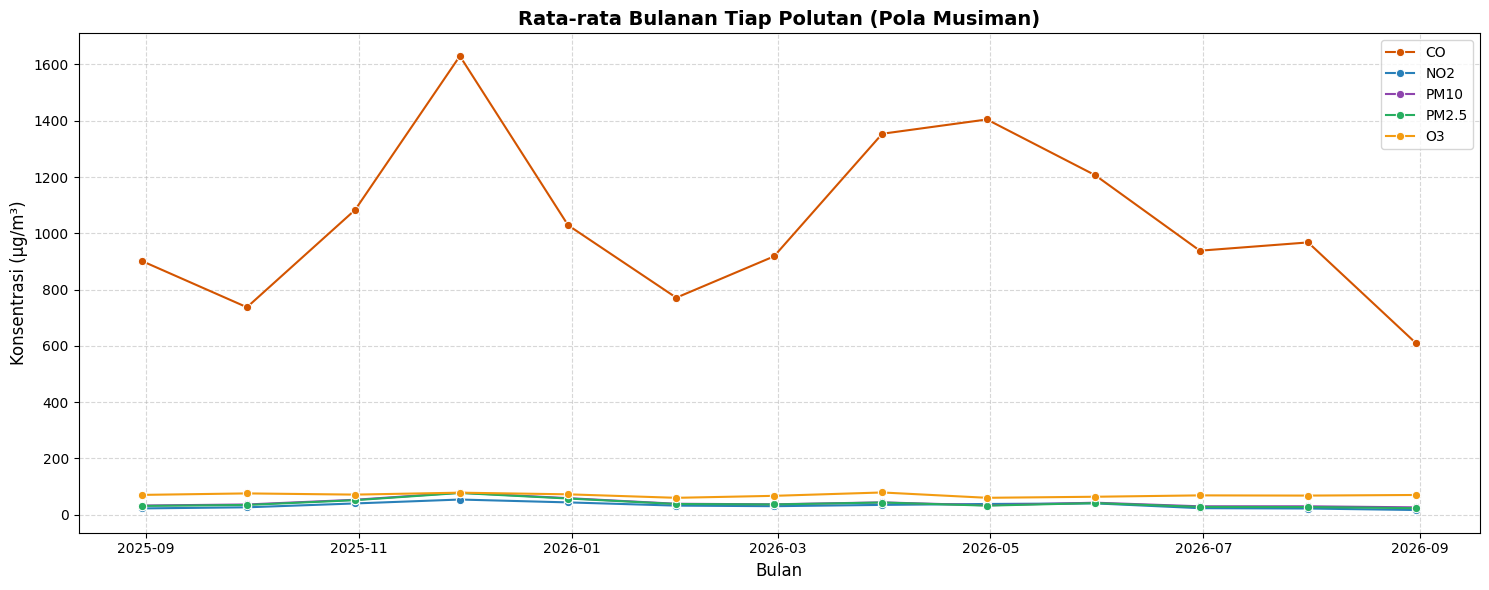

In [22]:
# Resample menjadi rata-rata bulanan untuk melihat tren musiman
df_monthly = df.resample('M', on='time').mean(numeric_only=True).reset_index()

plt.figure(figsize=(15, 6))
for col, color in zip(['CO', 'NO2', 'PM10', 'PM2.5', 'O3'],
                       ['#d35400', '#2980b9', '#8e44ad', '#27ae60', '#f39c12']):
    sns.lineplot(data=df_monthly, x='time', y=col, label=col, color=color, marker='o')

plt.title('Rata-rata Bulanan Tiap Polutan (Pola Musiman)', fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Konsentrasi (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [23]:
# Klasifikasi musim: Kemarau (Apr-Okt) vs Hujan (Nov-Mar), pola umum Jawa Timur
def klasifikasi_musim(bulan):
    return 'Kemarau' if bulan in [4, 5, 6, 7, 8, 9, 10] else 'Hujan'

df['musim'] = df['time'].dt.month.apply(klasifikasi_musim)

# Perbandingan rata-rata konsentrasi tiap polutan antar musim
perbandingan_musim = df.groupby('musim')[['CO', 'NO2', 'PM10', 'PM2.5', 'O3']].mean()
print("Rata-rata konsentrasi polutan per musim:")
perbandingan_musim

Rata-rata konsentrasi polutan per musim:


,CO,NO2,PM10,PM2.5,O3
musim,,,,,
Hujan,1141.550497,39.352345,51.721716,50.858720,71.666115
Kemarau,991.464729,29.750194,36.199922,34.271492,68.514922


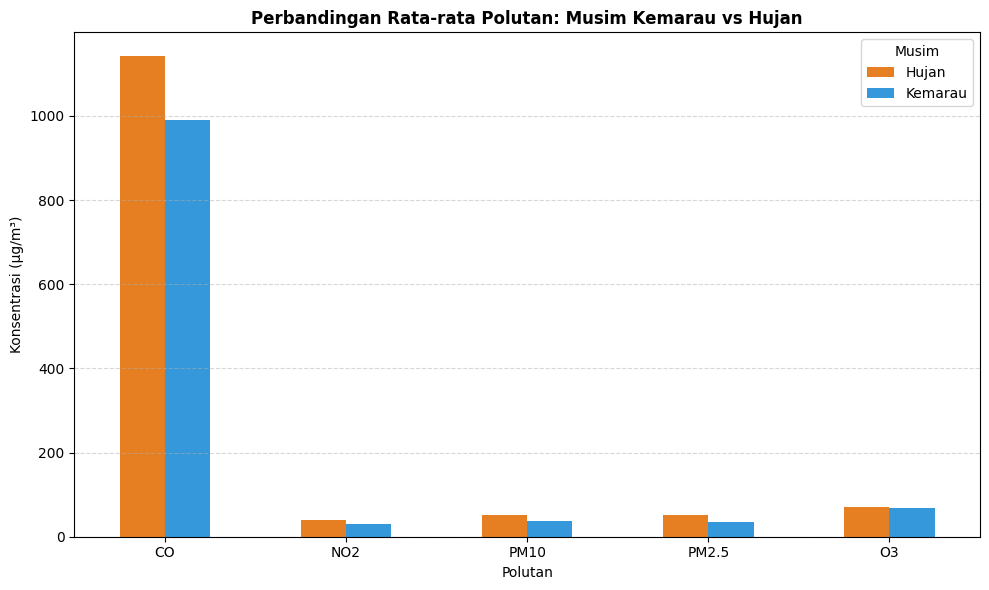

In [24]:
perbandingan_musim.T.plot(kind='bar', figsize=(10, 6), color=['#e67e22', '#3498db'])
plt.title('Perbandingan Rata-rata Polutan: Musim Kemarau vs Hujan', fontweight='bold')
plt.ylabel('Konsentrasi (μg/m³)')
plt.xlabel('Polutan')
plt.xticks(rotation=0)
plt.legend(title='Musim')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## F. Frekuensi Pelanggaran Ambang Batas Aman

Bagian ini menjawab pertanyaan riset terakhir: "polutan mana yang paling sering melebihi ambang batas aman?", menggunakan baku mutu udara ambien nasional (PP No. 22 Tahun 2021) yang sudah dijelaskan pada Bagian 2.3.

In [25]:
# Baku mutu udara ambien nasional (PP No. 22 Tahun 2021), dalam μg/m³
baku_mutu = {
    'CO': 10000,     # rata-rata 1 jam
    'NO2': 200,      # rata-rata 1 jam
    'PM10': 75,      # rata-rata 24 jam
    'PM2.5': 55,     # rata-rata 24 jam
    'O3': 150        # rata-rata 1 jam
}

hasil_pelanggaran = []
for polutan, batas in baku_mutu.items():
    jumlah_lewat = (df[polutan] > batas).sum()
    total_data = df[polutan].notna().sum()
    persen_lewat = (jumlah_lewat / total_data) * 100
    hasil_pelanggaran.append({
        'Polutan': polutan,
        'Baku Mutu (μg/m³)': batas,
        'Jumlah Jam Melebihi': jumlah_lewat,
        'Persentase Waktu Melebihi (%)': round(persen_lewat, 2)
    })

df_pelanggaran = pd.DataFrame(hasil_pelanggaran).sort_values(
    by='Persentase Waktu Melebihi (%)', ascending=False
).reset_index(drop=True)

print("Ringkasan frekuensi pelanggaran ambang batas per polutan:")
df_pelanggaran

Ringkasan frekuensi pelanggaran ambang batas per polutan:


,Polutan,Baku Mutu (μg/m³),Jumlah Jam Melebihi,Persentase Waktu Melebihi (%)
0,PM2.5,55,1867,21.25
1,PM10,75,1049,11.94
2,O3,150,902,10.27
3,CO,10000,0,0.00
4,NO2,200,0,0.00


C:\Users\OKAN\AppData\Local\Temp\ipykernel_4372\859491421.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pelanggaran, x='Polutan', y='Persentase Waktu Melebihi (%)', palette='Reds_r')


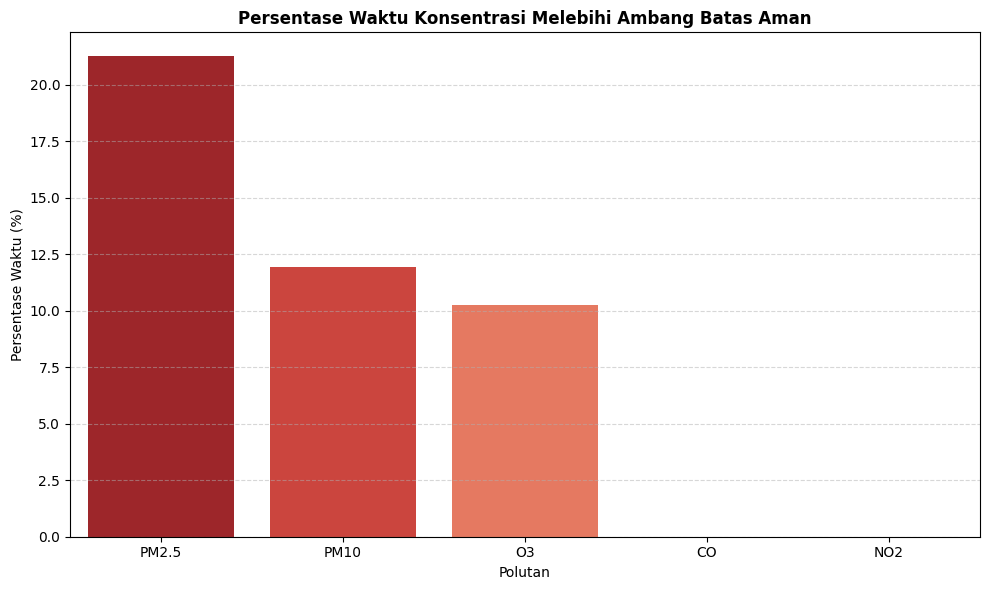

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_pelanggaran, x='Polutan', y='Persentase Waktu Melebihi (%)', palette='Reds_r')
plt.title('Persentase Waktu Konsentrasi Melebihi Ambang Batas Aman', fontweight='bold')
plt.ylabel('Persentase Waktu (%)')
plt.xlabel('Polutan')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

```{note}
Perlu diperhatikan bahwa baku mutu PM10, PM2.5 (rata-rata 24 jam) dan CO, NO2, O3 (rata-rata 1 jam) memiliki basis waktu rata-rata yang berbeda. Perhitungan di atas menerapkan ambang batas langsung pada data per jam sebagai pendekatan sederhana (screening); untuk kesimpulan yang lebih presisi terhadap PM10/PM2.5, idealnya dihitung dari rata-rata bergerak 24 jam (`df[col].rolling('24H').mean()`) sebelum dibandingkan dengan baku mutunya.
```

## G. Ringkasan Statistik Akhir

In [27]:
# Ringkasan statistik harian dari seluruh polutan setelah proses pembersihan
df_daily[['CO', 'NO2', 'PM10', 'PM2.5', 'O3']].describe()

,CO,NO2,PM10,PM2.5,O3
count,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1053.385360,33.711737,42.603723,41.114857,69.815005
std,478.200720,13.249563,19.071423,19.200405,15.514450
min,317.041667,10.295833,13.295833,11.700000,30.625000
25%,708.177083,23.195833,29.145833,27.498958,60.697917
50%,928.479167,31.531250,36.656250,35.418750,70.041667
75%,1277.750000,42.361458,53.157292,52.200000,78.708333
max,3202.875000,90.745833,121.845833,119.529167,118.750000


---